# Survival Analysis

This module introduces survival analysis, a specialized area for predicting time-to-event data with censoring.

## Learning Objectives

- Understand survival analysis concepts (censoring, survival function, hazard)
- Perform Kaplan-Meier estimation
- Fit Cox Proportional Hazards models


Survival Data:
      T  E    group
0   6.0  1  miR-137
1  13.0  1  miR-137
2  13.0  1  miR-137
3  13.0  1  miR-137
4  19.0  1  miR-137


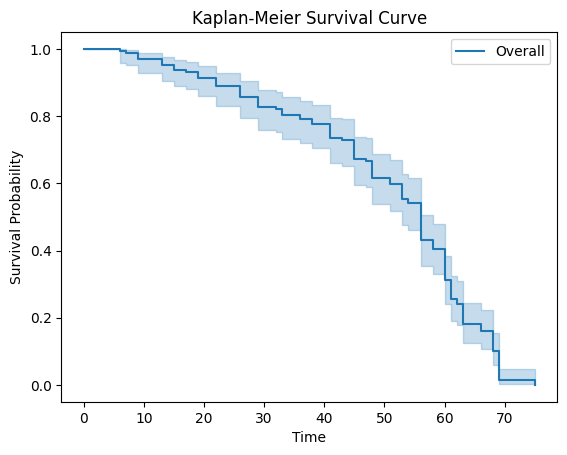

<lifelines.CoxPHFitter: fitted with 163 total observations, 7 right-censored observations>
             duration col = 'T'
                event col = 'E'
      baseline estimation = breslow
   number of observations = 163
number of events observed = 156
   partial log-likelihood = -613.18
         time fit was run = 2025-12-30 14:55:29 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
group[T.miR-137]  2.05      7.79      0.22            1.63            2.48                5.09               11.91

                  cmp to    z      p  -log2(p)
covariate                                     
group[T.miR-137]    0.00 9.46 <0.005     68.14
---
Concordance = 0.66
Partial AIC = 1228.36
log-likelihood ratio test = 66.25 on 1 df
-log2(p) of ll-ratio test = 51.16

In [1]:
from lifelines.datasets import load_waltons
from src.models.survival import fit_kaplan_meier, fit_cox_model, compare_survival_curves
import matplotlib.pyplot as plt
import pandas as pd

# Load example survival data
df = load_waltons()
print("Survival Data:")
print(df.head())

# Fit Kaplan-Meier estimator
kmf = fit_kaplan_meier(df['T'], df['E'], label='Overall')
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.show()

# Cox Proportional Hazards model
if 'group' in df.columns:
    cph = fit_cox_model(df, duration_col='T', event_col='E', formula='group')
    cph.print_summary()
